### xgb_ranker

In this notebook, we attempt to predict nomination-worthy novels using a year-by-year Learn-To-Rank model with XGBRanker.

In [2]:
import numpy as np
import csv
import pandas as pd
from itertools import islice
import json
import missingno as msno
import matplotlib.pyplot as plt
import sklearn
import sys

sys.path.append("../scripts")

In [3]:
books_tt = pd.read_csv('../data/books_engineered_train.csv')
books_tt.head()

,Unnamed: 0.1,Unnamed: 0,title,author,release_year,first_publisher,tags,hugo,locus,month_of_publication,...,tag_urban,tag_urban fantasi,tag_vampir,tag_video gam,tag_war,tag_weak character develop,tag_weird,tag_werewolf,tag_ya,tag_zombi
0,4548,4548,The Hawkstone,Jay Williams,1971,Other,[''],False,False,10,...,0,0,0,0,0,0,0,0,0,0
1,4549,4549,"Barnabas, Quentin and Dr. Jekyll's Son",Marilyn Ross,1971,Other,NaN,False,False,04,...,0,0,0,0,0,0,0,0,0,0
2,4550,4550,Swap Around the Ouija,John Dexter,1971,Other,NaN,False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0
3,4551,4551,The Sun Grows Cold,Howard Berk,1971,dell,['apocalyps'],False,False,01,...,0,0,0,0,0,0,0,0,0,0
4,4552,4552,The Seal-Singing,Rosemary Harris,1971,Other,['anim'],False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
sys.path.append("../scripts")
from feature_engineering.feature_engineering import tag_dataframe
from custom_yearly_scalers import YearByYearStandardScaler, YearlyGenreTagScaler, YearlyPastNomineeSimilarityScaler
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numerical_features = ["Total_Awards_Previously", "Author_Age_at_Publication", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

# for each categorical feature, create one-hot encoding
categorical_pipeline = Pipeline(
    steps=[
        ('solve_nans', SimpleImputer(fill_value='Unknown', strategy='constant')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ] 
)

# numerical features: z-score normalization with the rest of the year.
# turn bool features to int
# calculate similarities
feature_preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_scaling', YearByYearStandardScaler(year_column='release_year', scale_columns=numerical_features), numerical_features + ['release_year']),
        ('bool_to_int', FunctionTransformer(lambda x: x.astype(int), feature_names_out='one-to-one'), bool_features),
        ('onehot', categorical_pipeline, categorical_features),
    ('tag_similarity', YearlyGenreTagScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year']) ,
    ('nominee_similarity', YearlyPastNomineeSimilarityScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year'])    ],
)

We shall use **walk-forward nested time series cross-validation**.

In [6]:
from walkforward_cv import walk_forward

def walk_forward(data, initial_size=5, step=1):
    # data is a data
    years = data['release_year'].unique()
    num_years = len(years)
    splits = []

    for i in range(initial_size, num_years - step + 1):
        # print(num_years - initial_size - step + 1)
        data_start = 0
        data_end = i
        val_start = data_end
        val_end = val_start + step

        window = data[data['release_year'].isin(years[data_start:data_end])]
        val = data[data['release_year'].isin(years[val_start:val_end])]

        splits.append((window, val))

    return splits


windows = walk_forward(books_tt)


In [7]:
print(len(windows))

39


In [8]:
features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

import xgboost as xgb

model =  Pipeline(steps=[
        ('preprocess', feature_preprocessing),
        ('xgb_rank', xgb.XGBRanker(
    tree_method="hist",
    objective="rank:ndcg",
    eval_metric="ndcg@40", # because each year has < 60 nominees, we care most about ranking those.
    lambdarank_pair_method="topk",

    lambdarank_num_pair_per_sample=40, 
    
    max_depth=4,                       
    learning_rate=0.05,
    n_estimators=300,                  
    colsample_bytree=0.7,              
    subsample=0.8
))
])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38


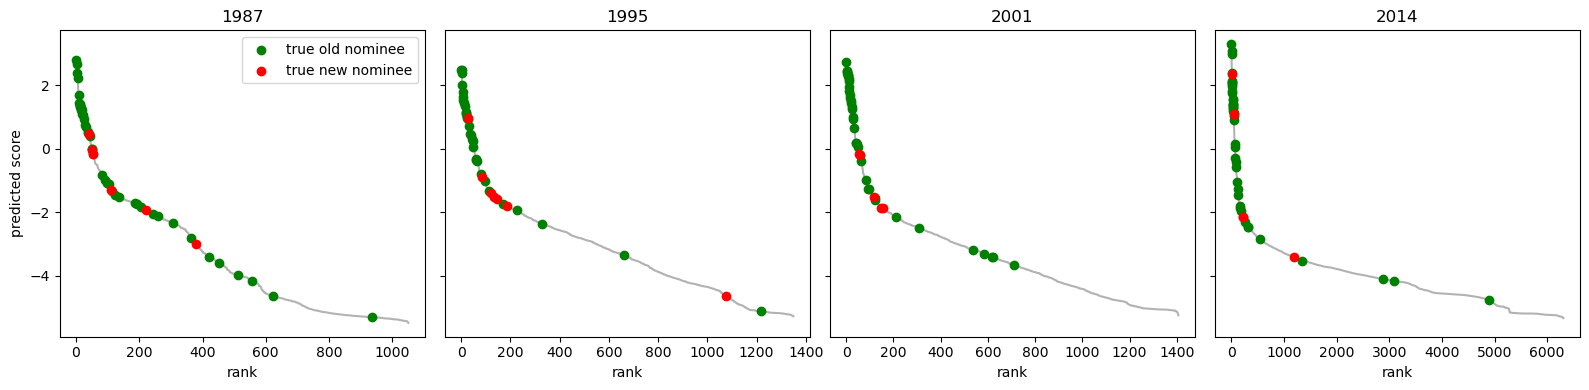

In [9]:
num_finalists = 60 # the top 60 ranked will be labeled as finalists.

from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score, ndcg_score
from sklearn.metrics import recall_score

cv_data = []
years_to_check = [1987, 1995, 2001, 2014]  # pick a mix: sparse, dense, recent, old

fig, axes = plt.subplots(1, len(years_to_check), figsize=(16, 4), sharey=True)

for num, fold in enumerate(windows):
    book_train = fold[0]
    book_val = fold[1]

    book_train = book_train.copy()
    book_val = book_val.copy()
    year = book_val['release_year'].mode()

    model.fit(
                book_train[features],
                book_train['target'],
                xgb_rank__qid=book_train['release_year'],
            )
    
    ypred = model.predict(book_val[features])
    book_val['predicted_score'] = ypred

    book_val['rank_within_year'] = book_val.groupby('release_year')['predicted_score'].rank(
            method='first', 
            ascending=False
        )
    
    book_val['predicted'] = (book_val['rank_within_year'] <= 60).astype(int)

    for ax, yr in zip(axes, years_to_check):
        if year[0] == yr:

            sub = book_val[book_val['release_year'] == yr].sort_values('rank_within_year')

            ax.plot(sub['rank_within_year'], sub['predicted_score'], color='gray', alpha=0.6)
            
            nominees = sub[sub['target'] == 1]
            new_nominees = nominees[nominees['new_author']==1]
            old_nominees = nominees[nominees['new_author']==0]
            ax.scatter(old_nominees['rank_within_year'], old_nominees['predicted_score'], 
                    color='green', zorder=5, label='true old nominee')
            ax.scatter(new_nominees['rank_within_year'], new_nominees['predicted_score'], 
                    color='red', zorder=5, label='true new nominee')

            ax.set_title(f'{yr}')
            ax.set_xlabel('rank')

    f1score = f1_score(book_val['target'], book_val['predicted'].values)
    recall = recall_score(book_val['target'], book_val['predicted'].values)
    precision = precision_score(book_val['target'], book_val['predicted'].values)

    cv_data.append({'fold': num, "val_year": year.values, 'f1_score': f1score, 'recall': recall, 'precision': precision})
    print(num)

axes[0].set_ylabel('predicted score')
axes[0].legend()
plt.tight_layout()
plt.show()


In [10]:
cv_result = pd.DataFrame(cv_data)
print("Mean f1 score across folds: ", cv_result['f1_score'].mean())
print("STD of f1 score across folds: ", cv_result['f1_score'].std())

Mean f1 score across folds:  0.5131609308621641
STD of f1 score across folds:  0.07785674816004355


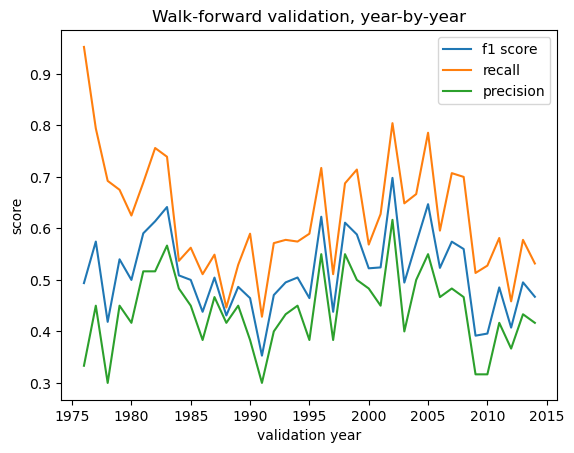

In [11]:
plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['recall'], label='recall')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['precision'], label='precision')
plt.xlabel("validation year")
plt.ylabel("score")
plt.title('Walk-forward validation, year-by-year')
plt.legend()

<Axes: >

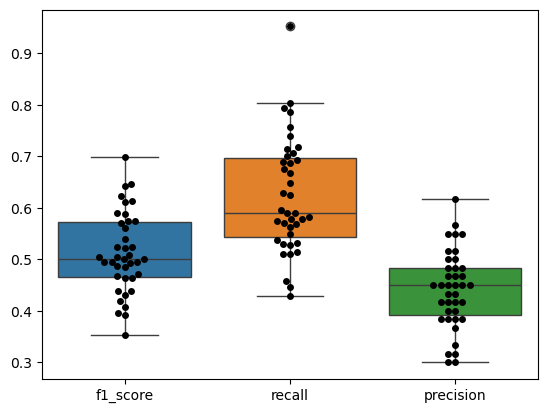

In [12]:
import seaborn as sns


ax = sns.boxplot(data=cv_result[['f1_score', 'recall', 'precision']])

sns.swarmplot(data=cv_result[['f1_score', 'recall', 'precision']], ax=ax, color='black')


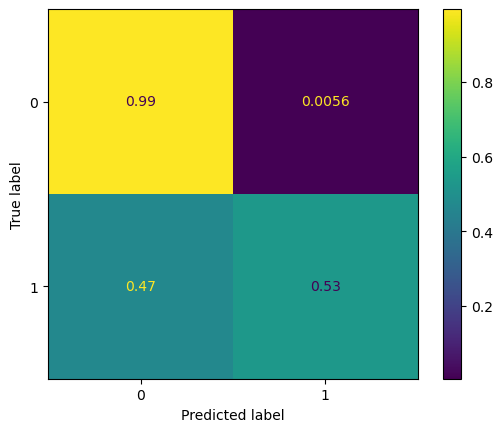

In [13]:
conf = confusion_matrix(book_val['target'], book_val['predicted'], normalize='true')#.ravel().tolist()

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=conf).plot()


Let us look at the most important features.

In [14]:
feature_names = model.named_steps['preprocess'].get_feature_names_out()

importances = model.named_steps['xgb_rank'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(20))

                                              Feature  Importance
0          numerical_scaling__Total_Awards_Previously    0.329555
3      numerical_scaling__years_since_last_nomination    0.166987
81         nominee_similarity__past_winner_similarity    0.047119
14                       onehot__first_publisher_avon    0.032649
2                 numerical_scaling__author_num_books    0.027966
80                 tag_similarity__cohort_similiarity    0.027107
48                onehot__first_publisher_pocketbooks    0.026474
46                  onehot__first_publisher_orbit(us)    0.020591
32                   onehot__first_publisher_gollancz    0.020112
29                     onehot__first_publisher_delrey    0.016902
4   numerical_scaling__publisher_historical_nomina...    0.016692
70                    onehot__month_of_publication_04    0.016277
79               onehot__month_of_publication_Unknown    0.016143
57                     onehot__first_publisher_signet    0.015784
69        

The fact that these models are so reliant on the # of total awards and the # of years since last nomination implies that they are not good at finding books by authors who have not previously been nominated. Let's see.

In [15]:
identified_noms = book_val[(book_val['target'] == 1) & (book_val['predicted'] == 1)]
unidentified_noms = book_val[(book_val['target'] == 1) & (book_val['predicted'] == 0)]

In [16]:
identified_noms['Total_Awards_Previously'].value_counts()

Total_Awards_Previously
1.0     7
2.0     4
6.0     3
22.0    2
9.0     2
3.0     2
13.0    2
5.0     1
14.0    1
18.0    1
Name: count, dtype: int64

In [17]:
unidentified_noms['Total_Awards_Previously'].value_counts()

Total_Awards_Previously
0.0    14
1.0     5
2.0     2
4.0     1
Name: count, dtype: int64

In [18]:
identified_noms['NomineeBefore'].value_counts()

NomineeBefore
True    25
Name: count, dtype: int64

In [19]:
unidentified_noms['NomineeBefore'].value_counts()

NomineeBefore
False    14
True      8
Name: count, dtype: int64

In [24]:
newbie_count

release_year
1971    12
1972    17
1973    14
1974    21
1975    19
1976    21
1977    34
1978    26
1979    40
1980    40
1981    45
1982    41
1983    46
1984    54
1985    48
1986    45
1987    51
1988    56
1989    51
1990    39
1991    42
1992    42
1993    45
1994    47
1995    39
1996    46
1997    45
1998    48
1999    42
2000    51
2001    43
2002    46
2003    37
2004    45
2005    42
2006    47
2007    41
2008    40
2009    37
2010    36
2011    43
2012    48
2013    45
2014    47
Name: new_author, dtype: int64

In [27]:
all_count

release_year
1971    12
1972    17
1973    14
1974    21
1975    19
1976    21
1977    34
1978    26
1979    40
1980    40
1981    45
1982    41
1983    46
1984    54
1985    48
1986    45
1987    51
1988    56
1989    51
1990    39
1991    42
1992    42
1993    45
1994    47
1995    39
1996    46
1997    45
1998    48
1999    42
2000    51
2001    43
2002    46
2003    37
2004    45
2005    42
2006    47
2007    41
2008    40
2009    37
2010    36
2011    43
2012    48
2013    45
2014    47
Name: title, dtype: int64

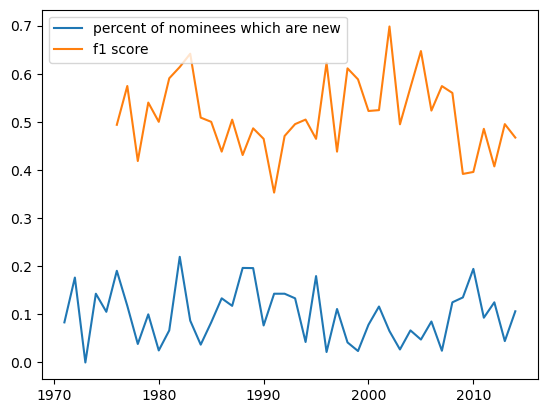

In [ ]:
newbie_count = books_tt[books_tt['target']].groupby('release_year')['new_author'].sum()
all_count = books_tt[books_tt['target']].groupby('release_year')['title'].count()

years = newbie_count.index.values
values = newbie_count.values

plt.plot(years, values/all_count.values, label = 'percent of nominees which are new')
# plt.plot(years, values/np.max(values), label = 'new nominees normalized')

plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')

plt.plot()
plt.legend()


It is not immediately clear that these are related..

### Improving on New author training

can we change anything about these features to try and improve this?

In [148]:
books_tt_copy = books_tt.copy()
books_tt_copy = books_tt_copy[books_tt_copy['new_author']]
books_tt_copy['author_success_fraction'] = books_tt_copy['Total_Awards_Previously'] / books_tt_copy['author_num_books']

numerical_features = ["Author_Age_at_Publication", 'publisher_historical_nominations']
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

# for each categorical feature, create one-hot encoding
categorical_pipeline = Pipeline(
    steps=[
        ('solve_nans', SimpleImputer(fill_value='Unknown', strategy='constant')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ] 
)

# numerical features: z-score normalization with the rest of the year.
# turn bool features to int
# calculate similarities
feature_preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_scaling', YearByYearStandardScaler(year_column='release_year', scale_columns=numerical_features), numerical_features + ['release_year']),
        ('bool_to_int', FunctionTransformer(lambda x: x.astype(int), feature_names_out='one-to-one'), bool_features),
        ('onehot', categorical_pipeline, categorical_features),
    ('tag_similarity', YearlyGenreTagScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year']) ,
    ('nominee_similarity', YearlyPastNomineeSimilarityScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year'])    ],
)

In [1]:
xgb_model1 =  Pipeline(steps=[
        ('preprocess', feature_preprocessing),
        ('xgb_rank', xgb.XGBRanker(
    tree_method="hist",
    objective="rank:ndcg",
    eval_metric="ndcg@50",             

    lambdarank_pair_method="topk",

    lambdarank_num_pair_per_sample=512, 
    
    max_depth=5,                       
    learning_rate=0.05,
    n_estimators=500,                  
    colsample_bytree=0.7,              
    subsample=0.8
))
])

windows = walk_forward(books_tt_copy)

NameError: name 'Pipeline' is not defined

In [155]:
cv_data = []

for num, fold in enumerate(windows):
    book_train = fold[0]
    book_val = fold[1]

    book_train = book_train.copy()
    book_val = book_val.copy()
    year = book_val['release_year'].mode()

    model.fit(
                book_train[features],
                book_train['target'],
                xgb_rank__qid=book_train['release_year'],
            )
    
    ypred = model.predict(book_val[features])
    book_val['predicted_score'] = ypred

    book_val['rank_within_year'] = book_val.groupby('release_year')['predicted_score'].rank(
            method='first', 
            ascending=False
        )
    
    book_val['predicted'] = (book_val['rank_within_year'] <= 10).astype(int)

    f1score = f1_score(book_val['target'], book_val['predicted'].values)
    recall = recall_score(book_val['target'], book_val['predicted'].values)
    precision = precision_score(book_val['target'], book_val['predicted'].values)

    cv_data.append({'fold': num, "val_year": year.values, 'f1_score': f1score, 'recall': recall, 'precision': precision})
    print(num)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38


In [156]:
cv_result = pd.DataFrame(cv_data)
print("Mean f1 score across folds: ", cv_result['f1_score'].mean())
print("STD of f1 score across folds: ", cv_result['f1_score'].std())

Mean f1 score across folds:  0.19880145191528856
STD of f1 score across folds:  0.13496700892101673


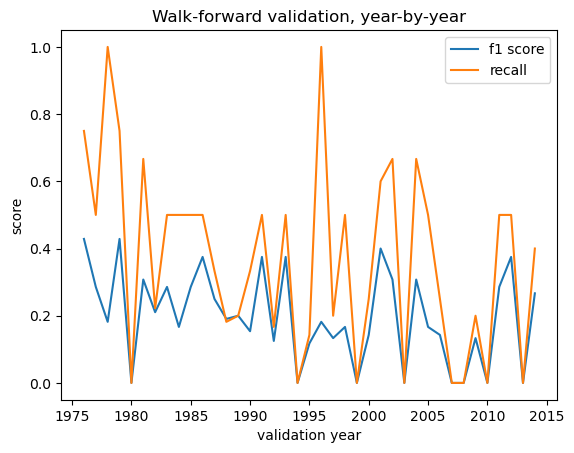

In [157]:
plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['recall'], label='recall')
plt.xlabel("validation year")
plt.ylabel("score")
plt.title('Walk-forward validation, year-by-year')
plt.legend()

<Axes: >

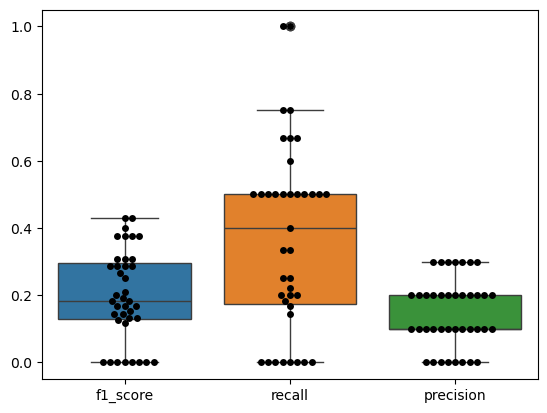

In [158]:
ax = sns.boxplot(data=cv_result[['f1_score', 'recall', 'precision']])

sns.swarmplot(data=cv_result[['f1_score', 'recall', 'precision']], ax=ax, color='black')


In [154]:
feature_names = model.named_steps['preprocess'].get_feature_names_out()

importances = model.named_steps['xgb_rank'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(20))

                                              Feature  Importance
77         nominee_similarity__past_winner_similarity    0.070833
7               onehot__first_publisher_alfreda.knopf    0.064169
15              onehot__first_publisher_bantamspectra    0.063847
1   numerical_scaling__publisher_historical_nomina...    0.052830
39                  onehot__first_publisher_macmillan    0.044987
16               onehot__first_publisher_berkleybooks    0.042308
65                    onehot__month_of_publication_03    0.039184
76                 tag_similarity__cohort_similiarity    0.037385
5                         onehot__first_publisher_ace    0.037166
67                    onehot__month_of_publication_05    0.031099
25                     onehot__first_publisher_delrey    0.030932
75               onehot__month_of_publication_Unknown    0.030364
41                      onehot__first_publisher_orbit    0.029936
59                        onehot__first_publisher_tor    0.029801
0        n